# Scaling and Column Transformation
# what is scaling 
# standard scaling - when Normal distribution 
# Min max scaling - when no outliers
# Robust Scaling - when outliers present and its important outliers

In [1]:
# Bias Prevention 
# Distance based Algo - KNN and SVM and K Mean Clustering 


# Standard scaling -  Xi - mean / STD

In [1]:
# z- score normalization 

In [25]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


In [26]:
df = pd.read_csv('titanic_data_updated.csv') 
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [27]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [28]:
# x er bhitor amra features raki 
X = df.drop(['Survived'],axis=1)
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [29]:
# target column 
y = df['Survived'] 
y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

<Axes: xlabel='Age', ylabel='Density'>

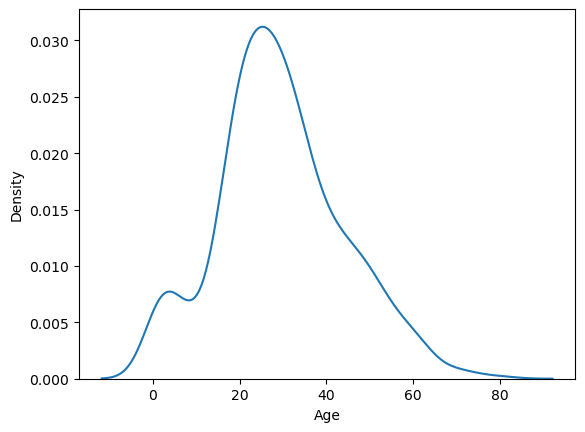

In [31]:
sns.kdeplot(data=X_train, x='Age')

In [32]:
from sklearn.preprocessing import OrdinalEncoder 

pclass_encoder = OrdinalEncoder(categories=[['third','second','first']])

pclass_encoder.fit(X_train[['Pclass']])

#transform 

X_train['encoded_pclass']= pclass_encoder.transform(X_train[['Pclass']]).ravel() 
X_test['encoded_pclass']= pclass_encoder.transform(X_test[['Pclass']]).ravel()


X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,encoded_pclass
331,first,male,45.5,0,0,28.5000,C124,S,2.0
733,second,male,23.0,0,0,13.0000,NaN,S,1.0
382,third,male,32.0,0,0,7.9250,NaN,S,0.0
704,third,male,26.0,1,0,7.8542,NaN,S,0.0
813,third,female,6.0,4,2,31.2750,NaN,S,0.0
...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,0.0
270,first,male,NaN,0,0,31.0000,NaN,S,2.0
860,third,male,41.0,2,0,14.1083,NaN,S,0.0
435,first,female,14.0,1,2,120.0000,B96 B98,S,2.0


In [33]:
from sklearn.preprocessing import OneHotEncoder 

sex_ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas') 

sex_ohe.fit(X_train[['Sex']]) 

encoded_df = sex_ohe.transform(X_train[['Sex']])
X_train = pd.concat([X_train,encoded_df],axis=1) 


In [34]:
embarked_ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas') 

embarked_ohe.fit(X_train[['Embarked']]) 
encoded_embarked = embarked_ohe.transform(X_train[['Embarked']]) 

X_train = pd.concat([X_train,encoded_embarked], axis=1) 
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
331,first,male,45.5,0,0,28.5000,C124,S,2.0,0.0,1.0,0.0,0.0,1.0,0.0
733,second,male,23.0,0,0,13.0000,NaN,S,1.0,0.0,1.0,0.0,0.0,1.0,0.0
382,third,male,32.0,0,0,7.9250,NaN,S,0.0,0.0,1.0,0.0,0.0,1.0,0.0
704,third,male,26.0,1,0,7.8542,NaN,S,0.0,0.0,1.0,0.0,0.0,1.0,0.0
813,third,female,6.0,4,2,31.2750,NaN,S,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,0.0,1.0,0.0,0.0,0.0,1.0,0.0
270,first,male,NaN,0,0,31.0000,NaN,S,2.0,0.0,1.0,0.0,0.0,1.0,0.0
860,third,male,41.0,2,0,14.1083,NaN,S,0.0,0.0,1.0,0.0,0.0,1.0,0.0
435,first,female,14.0,1,2,120.0000,B96 B98,S,2.0,1.0,0.0,0.0,0.0,1.0,0.0


In [35]:
# transforming test data
encoded_embarked = embarked_ohe.transform(X_test[['Embarked']]) 
X_test = pd.concat([X_test,encoded_embarked], axis=1) 

In [36]:
X_train.drop(['Pclass','Sex','Embarked'], axis=1, inplace=True)

In [37]:
X_test.drop(['Pclass','Sex','Embarked'], axis=1, inplace=True)

In [38]:
X_train['Cabin'].value_counts() 

Cabin
C23 C25 C27    4
C22 C26        3
F2             3
G6             3
B96 B98        3
              ..
A14            1
D49            1
C87            1
D56            1
C62 C64        1
Name: count, Length: 117, dtype: int64

In [39]:
X_train['Cabin_Deck'] = X_train['Cabin'].astype(str).str[0]
X_test['Cabin_Deck'] = X_test['Cabin'].astype(str).str[0]
X_train

,Age,SibSp,Parch,Fare,Cabin,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan,Cabin_Deck
331,45.5,0,0,28.5000,C124,2.0,0.0,1.0,0.0,0.0,1.0,0.0,C
733,23.0,0,0,13.0000,NaN,1.0,0.0,1.0,0.0,0.0,1.0,0.0,n
382,32.0,0,0,7.9250,NaN,0.0,0.0,1.0,0.0,0.0,1.0,0.0,n
704,26.0,1,0,7.8542,NaN,0.0,0.0,1.0,0.0,0.0,1.0,0.0,n
813,6.0,4,2,31.2750,NaN,0.0,1.0,0.0,0.0,0.0,1.0,0.0,n
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.0,0,0,7.6500,NaN,0.0,1.0,0.0,0.0,0.0,1.0,0.0,n
270,NaN,0,0,31.0000,NaN,2.0,0.0,1.0,0.0,0.0,1.0,0.0,n
860,41.0,2,0,14.1083,NaN,0.0,0.0,1.0,0.0,0.0,1.0,0.0,n
435,14.0,1,2,120.0000,B96 B98,2.0,1.0,0.0,0.0,0.0,1.0,0.0,B


In [40]:
X_train['Cabin_Deck'].value_counts()

Cabin_Deck
n    553
C     52
B     38
E     24
D     19
F     12
A     10
G      3
T      1
Name: count, dtype: int64

In [41]:
deck_ohe = OneHotEncoder(sparse_output=False,drop='first').set_output(transform='pandas') 

deck_ohe.fit(X_train[['Cabin_Deck']]) 
encoded_deck = deck_ohe.transform(X_train[['Cabin_Deck']]) 

X_train = pd.concat([X_train,encoded_deck], axis=1) 
X_train

,Age,SibSp,Parch,Fare,Cabin,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,...,Embarked_nan,Cabin_Deck,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_T,Cabin_Deck_n
331,45.5,0,0,28.5000,C124,2.0,0.0,1.0,0.0,0.0,...,0.0,C,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,23.0,0,0,13.0000,NaN,1.0,0.0,1.0,0.0,0.0,...,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
382,32.0,0,0,7.9250,NaN,0.0,0.0,1.0,0.0,0.0,...,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
704,26.0,1,0,7.8542,NaN,0.0,0.0,1.0,0.0,0.0,...,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
813,6.0,4,2,31.2750,NaN,0.0,1.0,0.0,0.0,0.0,...,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.0,0,0,7.6500,NaN,0.0,1.0,0.0,0.0,0.0,...,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
270,NaN,0,0,31.0000,NaN,2.0,0.0,1.0,0.0,0.0,...,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
860,41.0,2,0,14.1083,NaN,0.0,0.0,1.0,0.0,0.0,...,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
435,14.0,1,2,120.0000,B96 B98,2.0,1.0,0.0,0.0,0.0,...,0.0,B,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
encoded_deck = deck_ohe.transform(X_test[['Cabin_Deck']]) 

X_test = pd.concat([X_test,encoded_deck], axis=1) 
X_test

,Age,SibSp,Parch,Fare,Cabin,encoded_pclass,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan,Cabin_Deck,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_T,Cabin_Deck_n
709,NaN,1,1,15.2458,NaN,0.0,1.0,0.0,0.0,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
439,31.0,0,0,10.5000,NaN,1.0,0.0,0.0,1.0,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
840,20.0,0,0,7.9250,NaN,0.0,0.0,0.0,1.0,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
720,6.0,0,1,33.0000,NaN,1.0,0.0,0.0,1.0,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
39,14.0,1,0,11.2417,NaN,0.0,1.0,0.0,0.0,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,17.0,0,0,7.1250,NaN,0.0,0.0,0.0,1.0,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
773,NaN,0,0,7.2250,NaN,0.0,1.0,0.0,0.0,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
25,38.0,1,5,31.3875,NaN,0.0,0.0,0.0,1.0,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
84,17.0,0,0,10.5000,NaN,1.0,0.0,0.0,1.0,0.0,n,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [43]:
X_train.drop('Cabin_Deck', axis=1, inplace=True)
X_test.drop('Cabin_Deck', axis=1, inplace=True)

In [44]:
from sklearn.preprocessing import LabelEncoder 

le = LabelEncoder() 

#fit 

le.fit(y_train) 
#transform 

y_train_array = le.transform(y_train) 

y_test_array = le.transform(y_test)

In [45]:
y_train= pd.Series(y_train_array,index=y_train.index,name=y_train.name) 
y_test = pd.Series(y_test_array,index=y_test.index,name=y_test.name) 

<Axes: xlabel='Age', ylabel='Density'>

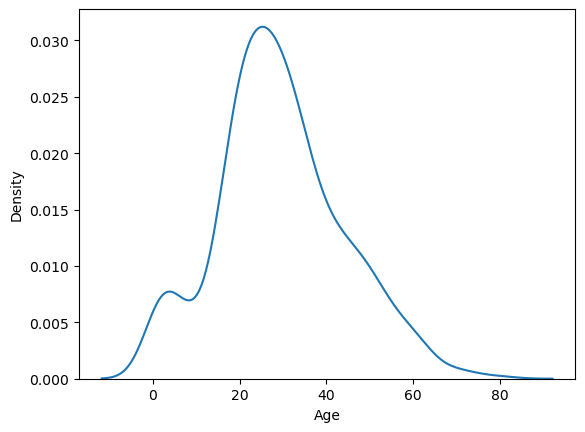

In [46]:
sns.kdeplot(data=X_train, x='Age')

In [48]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(X_train[['Age']])
X_train['Age']= ss.transform(X_train[['Age']]).ravel()
X_test['Age']= ss.transform(X_test[['Age']]).ravel()

In [49]:
X_train.sample(5)

,Age,SibSp,Parch,Fare,Cabin,encoded_pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_T,Cabin_Deck_n
37,-0.586638,0,0,8.0500,NaN,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
683,-1.069817,5,2,46.9000,NaN,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
36,NaN,0,0,7.2292,NaN,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
542,-1.276894,4,2,31.2750,NaN,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
152,1.794745,0,0,8.0500,NaN,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [50]:
X_train['Age'].mean()

np.float64(-1.467357703875207e-16)

In [51]:
X_train['Age'].std()

1.0008752736905386

<Axes: xlabel='Age', ylabel='Density'>

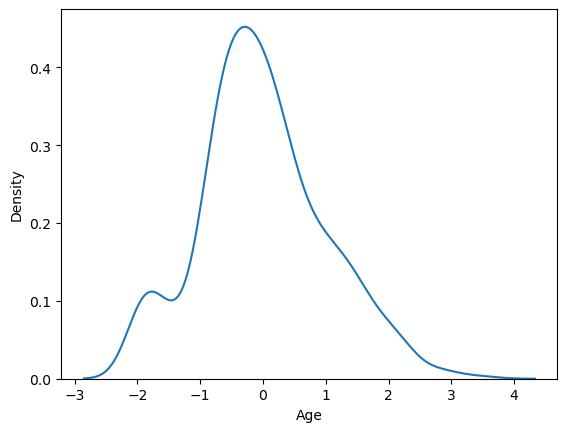

In [52]:
sns.kdeplot(data=X_train, x='Age')

# Min Max scaling Xi -min / Max - Min

<Axes: xlabel='Fare', ylabel='Density'>

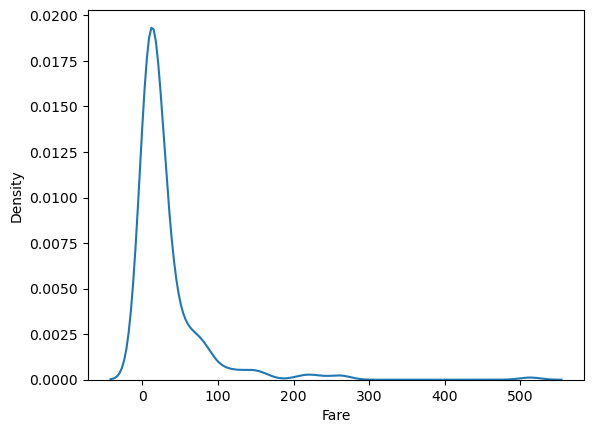

In [53]:
sns.kdeplot(data=X_train, x='Fare')

In [55]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler() 
mms.fit(X_train[['Fare']]) 
X_train['Fare'] = mms.transform(X_train[['Fare']]).ravel()
X_test['Fare'] = mms.transform(X_test[['Fare']]).ravel()


In [57]:
X_train['Fare'].describe()

count    712.000000
mean       0.063604
std        0.101438
min        0.000000
25%        0.015469
50%        0.028213
75%        0.059532
max        1.000000
Name: Fare, dtype: float64

<Axes: xlabel='Fare', ylabel='Density'>

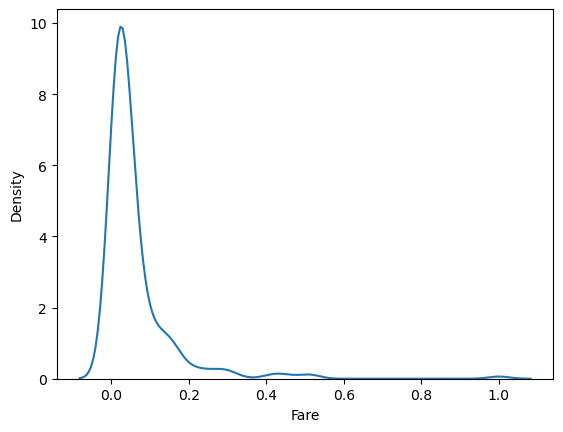

In [58]:
sns.kdeplot(data=X_train, x='Fare')

# Robust Scaller - Xi - Median / IQR
